# **Note For Colab Users**

# **Do Not Write Directly In This File, Or Your Work May Disappear!**

# **Always Make A Copy Before You Start.**

How to make a copy

1. Click "File" in the top left  
> *If you cannot see menus like "File" or "Runtime", press the "v" mark in the top right to show them.*

2. Choose "Save a copy in Drive"  

3. Rename the copied file to "YOURNAMEs_FileName.ipynb"  
> Example: if your name is Olivia -> Olivias_FileName.ipynb  


---

* Check marks (✅) are not saved. They disappear when you refresh the page with Chrome's reload button.<br>  
If you stop halfway, add a text cell and write something like "SO FAR DONE".

---

* In Colab, **previous outputs are reset every 30 to 90 minutes**.<br>  
So errors like `~~ is not defined` happen **very often**.

🔁 What should you do if you see a `~~ is not defined` error?

1. First, check the spelling of the variable name.<br>  
2. If the spelling is correct and the error still appears, **click that cell to select it**.<br>  
3. Click "Runtime" -> "Run before" in the top left.<br>  
-> This reruns all cells up to that point.


**References**


# **Chapter 28: Instruction Tuning**

In this Chapter, we will do Instruction Tuning.<br>

We start from the pretrained model from the previous Chapter, then train it on prompt-response data.

The goal is to make the model answer like an assistant instead of continuing text like a blog.


## **Section 1: Loading The Pretrained Model**


We will use a G4 GPU again. Use the remaining credits from the previous pretraining run.<br>


**`Check Point`** <label><input type="checkbox"> Confirmed that you are connected to a G4 GPU.</label>


First, load the weights of the pretrained model trained in the previous Chapter.


The model class is the same as last time.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # vocabulary sizexembedding dimension of Define the embedding table
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # Get embedding vectors for the input indices
        return self.token_embedding_table.forward(input_indices)


class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # Clamp relative distance to the range [0, max_distance - 1] clamp(clip negative and too-large distances)
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # Get the corresponding bias vector from the embedding layer
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # Follow the step explained above
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # batch, token length, embedding channels

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Calculating Attention scores (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # Follow the step explained above
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # Follow the step explained above
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # Mask applied
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # Softmax → Dropout → weighted sum
        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleList with manage multiple heads
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # linear layer that mixes head outputs
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # Get each head output
        # Follow the step explained above
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # Concatenate all head outputs → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # Mix outputs with a linear transform
        projected = self.output_projection.forward(concatenated)

        return projected

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # eachLayerNorm keeps its own beta and gamma.
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # the forward method call is omitted.
        normed_input = self.layer_norm1(input_tensor) # Apply LayerNorm to the input
        attention_output = self.multihead_attention(normed_input) # Apply multi-head attention
        residual_attention = attention_output + input_tensor # Follow the step explained above
        normed_attention = self.layer_norm2(residual_attention) # Apply LayerNorm again to the residual output
        feedforward_output = self.feed_forward(normed_attention) # Apply the feed-forward network
        final_output = feedforward_output + residual_attention # Follow the step explained above

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # Layer normalization
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # Follow the step explained above
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Follow the step explained above
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # Follow the step explained above
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


Use the class name you used last time.


In [ ]:
class _______sGPT(nn.Module): # TODO: FILL
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # Keep this because it is also used during generation.
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # Calculate logits and loss
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # Follow the step explained above
        # Follow the step explained above
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # Generate text
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # Follow the step explained above
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # Crop the input

            # Follow the step explained above
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # Extract the logits for the last token
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Follow the step explained above

            # Sample the next token
            next_token = torch.multinomial(probs, num_samples=1)

            # Append the new token, input_indices update.
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # Follow the step explained above
        return input_indices

The Config class is also the same as last time.


In [ ]:
class Config:
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_training_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280
    hidden_dim: int = 5120
    num_attention_heads: int = 10
    layer_count: int = 20
    num_relative_positions = 1024

    # === optimization ===
    max_learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"

In [ ]:
config = Config()

Create a model instance. At this point, the model parameters, such as weights and biases, are randomly initialized.


In [ ]:
"""DELETE
model = EveryonesGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type) # TODO: FILL
"""
########## NEW ##########
vocab_size = 50257
# Do not move it to GPU yet.
model = _______sGPT(vocab_size = vocab_size, config = config) # TODO: FILL
########## NEW ##########

As in the previous Chapter, we compile the model for speed.


In [ ]:
# ⚠️ Don't run this cell twice!
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)

Right now, the model parameters, such as weights and biases, are randomly initialized.

Next, we load the checkpoint so the model becomes the pretrained model.


Log in to HuggingFace.


In [ ]:
from huggingface_hub import login
login()

Download the checkpoint from the previous pretraining run.


In [ ]:
from huggingface_hub import hf_hub_download
model_repo_id = "YOURNAME/EveryonesGPT-checkpoints" # TODO: FILL "HayatoHongo/EveryonesGPT-checkpoints"
checkpoint_path = "checkpoints/checkpoint_010000.pt" # TODO: FILL "checkpoints/checkpoint_010000.pt"
hf_hub_download(repo_id=model_repo_id, repo_type="model", filename=checkpoint_path, local_dir=".")

```python
checkpoint_data = torch.load(checkpoint_path, map_location="cpu")
```

Load the checkpoint file with `torch.load`.


In [ ]:
checkpoint_data = # TODO: output = function(arguments)

```python
model.load_state_dict(checkpoint_data["model_state_dict"])
```

Load the pretrained parameters into the model instance.


In [ ]:
# TODO: instance.method(arguments)

Now the model instance has loaded the parameter values from the pretrained model.


In [ ]:
compiled_model.to("cuda")

Let’s check inference with the pretrained model!


In [ ]:
import tiktoken
compiled_model.eval()
prompt = "What is the capital of Japan?"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # Encode text into IDs
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # Convert the list of IDs into a tensor
encoded_tensor = encoded_tensor.unsqueeze(0)  # Add a batch dimension
encoded_tensor = encoded_tensor.to(config.device_type) # Move encoded_tensor to cuda (GPU)
generated_tensor = compiled_model.generate(encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # Follow the step explained above
generated_text = tokenizer.decode(generated_ids) # Follow the step explained above
print(generated_text)

**`Check Point`** <label><input type="checkbox"> Ran inference 5 times and checked the output pattern.</label>


The pretrained model tends to explain things forever like a blog, or repeat questions.

That is normal for a pretrained text-completion model. It has not yet learned assistant-style responses.


## **Section 2: Create A Conversation Dataset**


Creating a conversation dataset by hand is hard, so we use a dataset generated with Microsoft’s instruction-tuned model [Phi-3](https://huggingface.co/microsoft/Phi-3-medium-128k-instruct).

This gives us prompt-response pairs for Instruction Tuning.


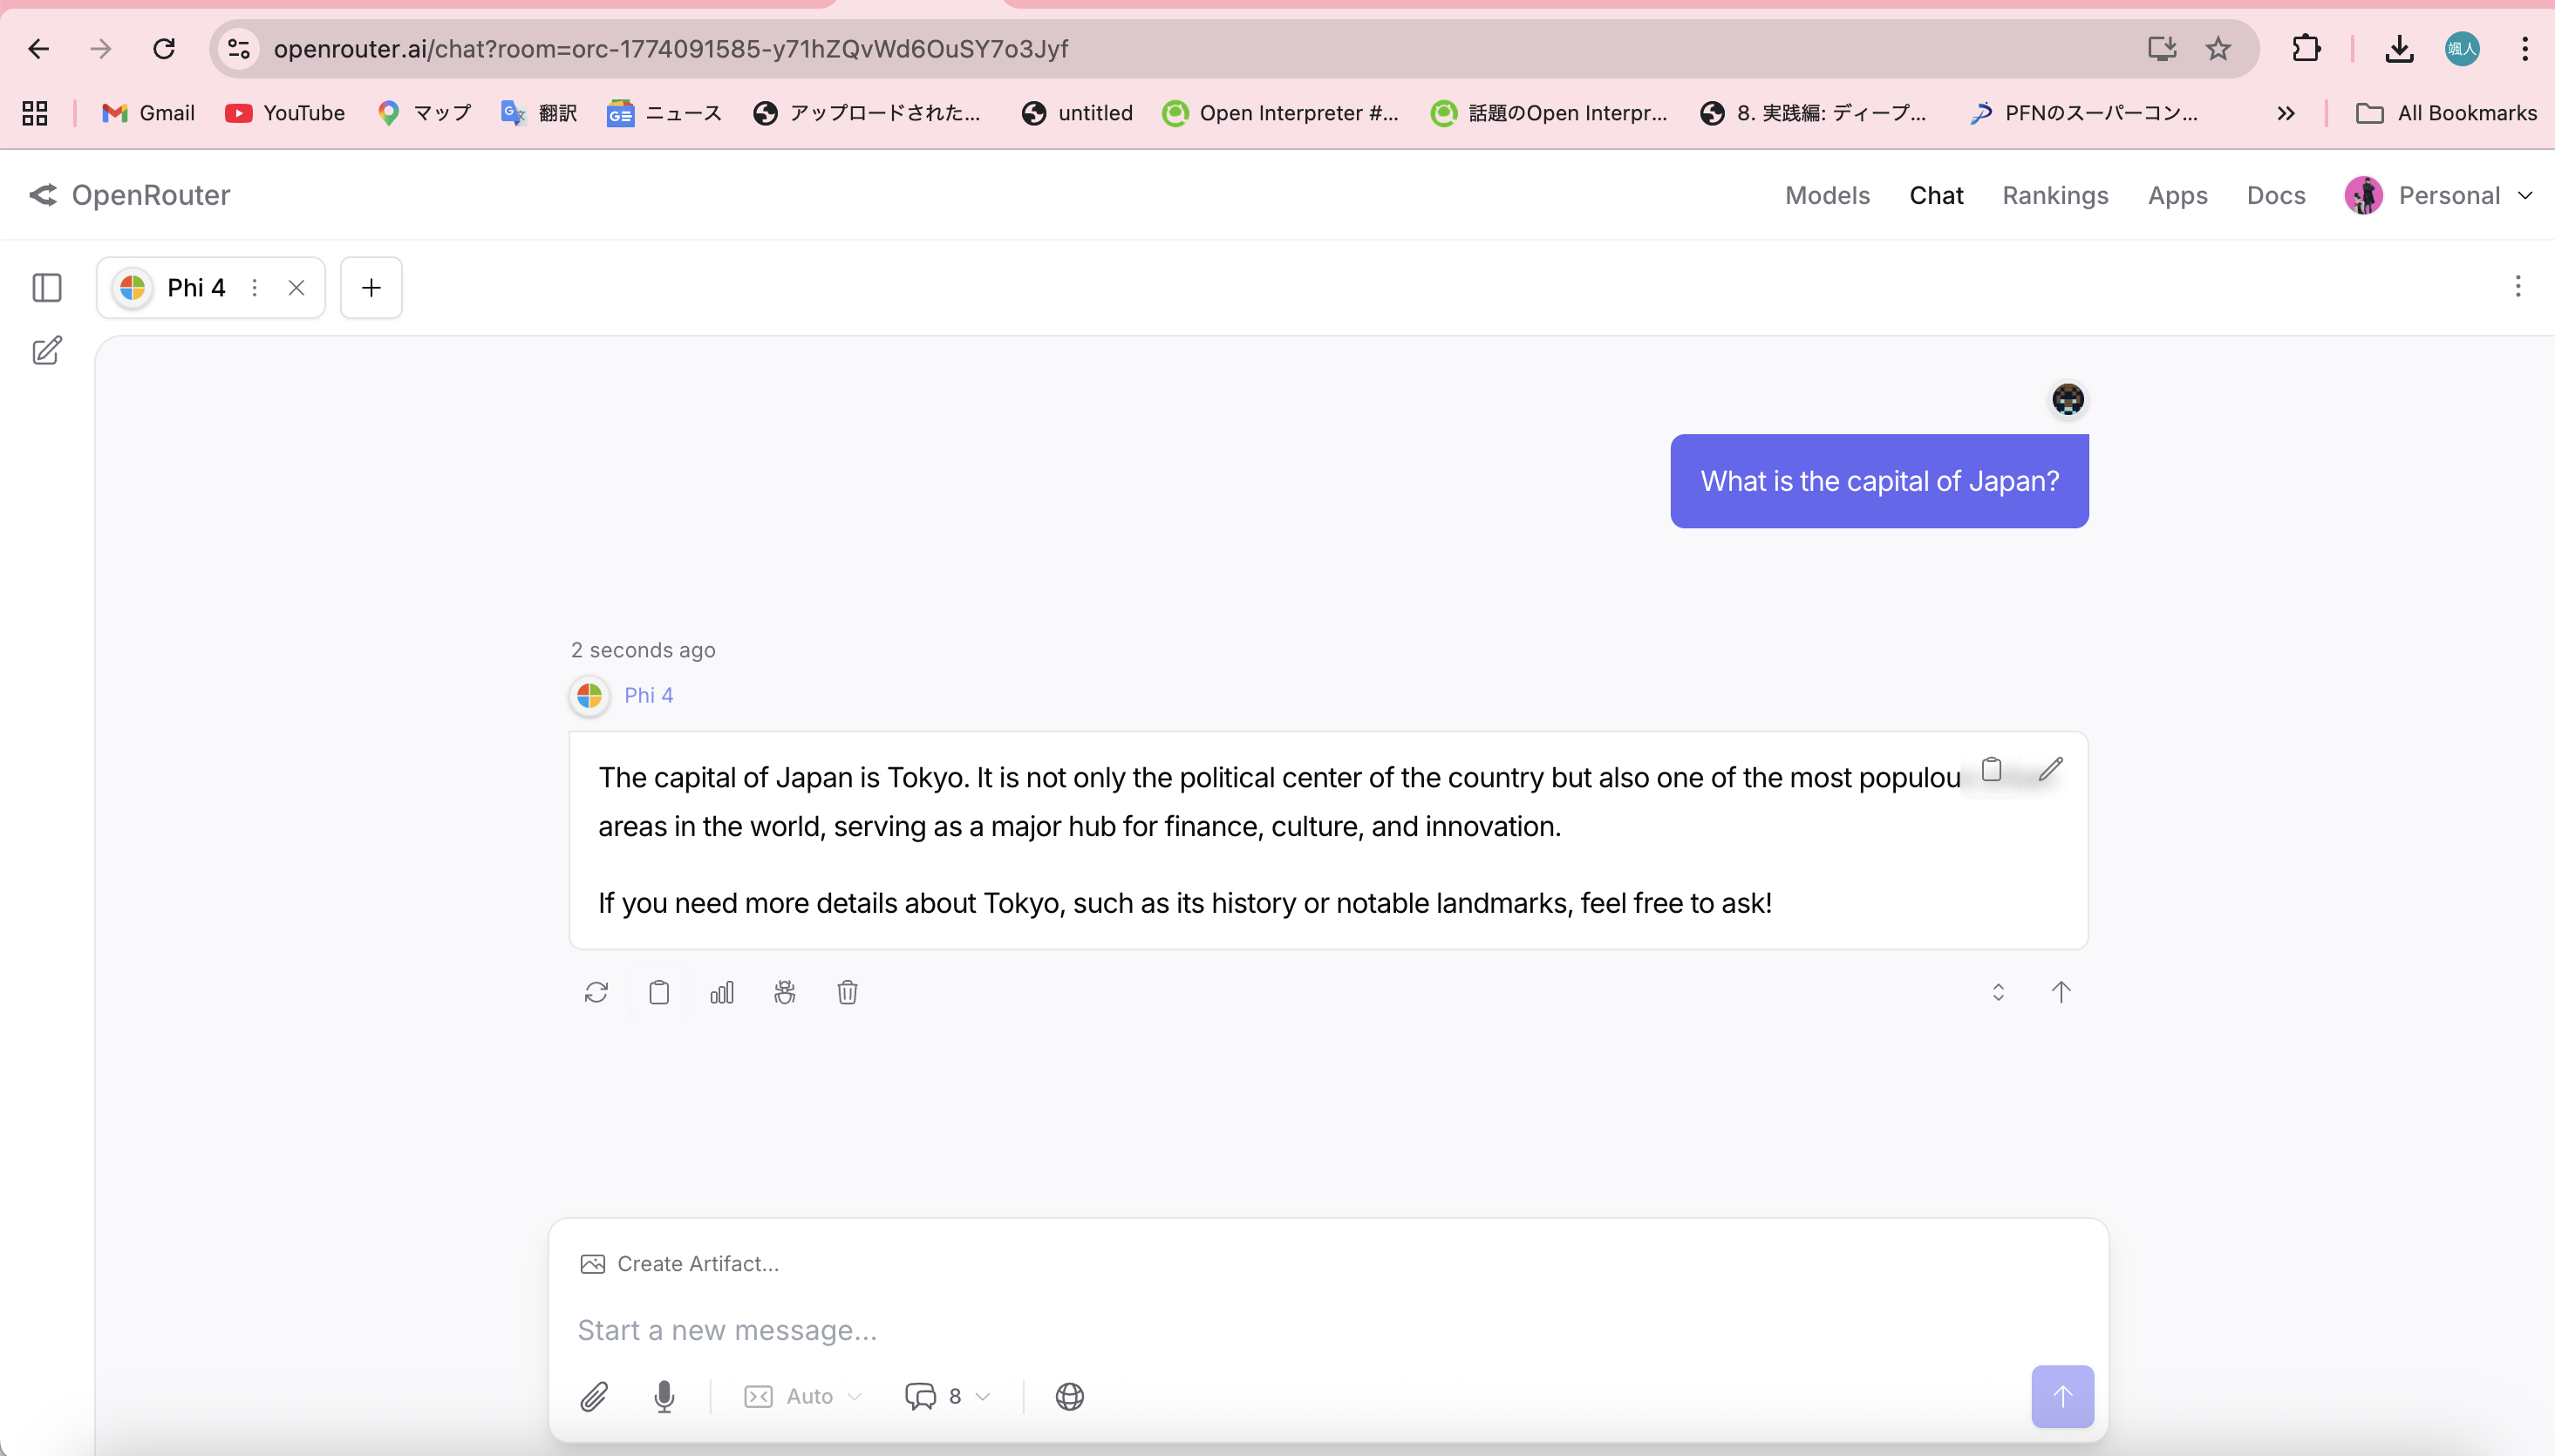

Actually, not only the answers but also the questions can be generated by a model.

This is a practical way to build a first instruction dataset.


In [ ]:
from huggingface_hub import hf_hub_download
data_repo_id = "HayatoHongo/Magpie-Phi3-Pro-1M-v0.1"
file_path = "sft_prompt_response_phi3.jsonl"
hf_hub_download(repo_id=data_repo_id, repo_type="dataset", filename=file_path, local_dir=".")

Let’s check a few samples from the beginning.


In [ ]:
!head "/content/sft_prompt_response_phi3.jsonl"

Convert the `.jsonl` data above into one large `.txt` file.

Each sample will be formatted with tags, so the model can learn where the user ends and where the AI answer begins.


![nanoGPT-Instruction-tuning-textdata.gif](https://github.com/HayatoHongo/Everyones_nanoGPT/raw/main/assets/nanoGPT-Instruction-tuning-textdata.gif)

⚠️ There is a fill-in-the-blank question!


In [ ]:
import json
input_path= "/content/sft_prompt_response_phi3.jsonl"
output_path = "/content/prompt_response_phi3_formatted.txt"

# read mode
input_file = open(input_path, "r", encoding="utf-8")
# write mode
output_file = open(output_path, "w", encoding="utf-8")

for line in input_file:
    item = json.loads(line)
    prompt = item["prompt"]
    response = # TODO:THINK_BY_YOURSELF
    formatted_text = f"<USER>{prompt}<AI>{response}<|endoftext|>"
    output_file.write(formatted_text)

input_file.close()
output_file.close()

In [ ]:
!head "/content/prompt_response_phi3_formatted.txt"

Encode the text data above with `tiktoken`, then save it as a NumPy file.


In [ ]:
import numpy as np

input_text_path = "/content/prompt_response_phi3_formatted.txt"
output_npy_path = "/content/prompt_response_phi3_formatted.npy"

# 1. Read the text
with open(input_text_path, "r", encoding="utf-8") as f:
    text = f.read()

# Follow the step explained above
tokenizer = tiktoken.get_encoding("gpt2")

# Follow the step explained above
tokens = tokenizer.encode(text, allowed_special="all")

# Follow the step explained above
token_array = np.array(tokens, dtype=np.int32)

# Follow the step explained above
np.save(output_npy_path, token_array)

print("Save complete:", output_npy_path)
print("Token count:", len(token_array))

Check the first 100 elements.


In [ ]:
print("token_array[:100]\n", token_array[:100])

Now the conversation dataset is ready!


In [ ]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # large tokenized file(.npy) open as a memory map, 
        # data loader that randomly reads only the needed parts.
        self.config = config  # Follow the step explained above
        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab
        # Follow the step explained above
        self.data = np.load(npy_path, mmap_mode="r")

    def get_batch(self):

        # Follow the step explained above
        # Follow the step explained above
        # Follow the step explained above
        range_start, range_end = 0, len(self.data)

        # Choose random start positions
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # Create a batch by taking consecutive token sequences from each start position
        # Pytorch of `nn.Embedding` torch.int64 only accepts.
        # Follow the step explained above
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # Use the next token as the target
        # Follow the step explained above
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # Move to a device such as GPU
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

In [ ]:
data_loader = # TODO: THINK_BY_YOURSELF

## **Section 3: Model Training**

The training functions and classes are the same as in the previous Chapter.


In [ ]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_training_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


In [ ]:
import os

def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")


def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_data["model_state_dict"])
    optimizer.load_state_dict(checkpoint_data["optimizer_state_dict"])
    print(f"[INFO] Resume completed at step {step}")

In [ ]:
import time

from huggingface_hub import hf_hub_download
from huggingface_hub import create_repo
from huggingface_hub import upload_file


class Trainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, repo_id, start_step=0):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir

        self.repo_id = repo_id

        self.start_step = start_step

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # Get a training batch.
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # Follow the step explained above

        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):

            logits, loss = self.model(input_batch, target_batch)

        loss.backward()  # backpropagation
        self.optimizer.step()  # parameter update

        return loss.item() # Return the loss value

    def train(self):
        if self.start_step > 0:
            checkpoint_filename = f"checkpoint_{self.start_step:06d}.pt"
            checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
            hf_hub_download(repo_id=self.repo_id, filename=checkpoint_path, local_dir=".")
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)

        total_train_time = 0
        last_log_time = time.time()

        # Follow the step explained above
        for step in range(self.start_step+1, self.config.total_training_steps+1):
            # learning rate of update
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # Follow the step explained above
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)

                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                checkpoint_filename = f"checkpoint_{step:06d}.pt"
                checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
                upload_file(repo_id=self.repo_id, path_or_fileobj=checkpoint_path, path_in_repo=checkpoint_path)


            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

In [ ]:
# close to nanoGPT setting
optimizer = torch.optim.AdamW(
    model.parameters(),
    betas=(0.9, 0.95),
    weight_decay=0.1,
    fused=True,
)

In general, the learning rate for Instruction Tuning is less than 1/10 of the pretraining learning rate.<br>

The model already knows language. We only want to gently teach it how to answer.


In [ ]:
"""DELETE
config.max_learning_rate = 2e-3
config.min_learning_rate = 2e-4
config.total_training_steps = 100_000
config.checkpoint_save_frequency = 10_000
"""
########## NEW ##########
config.max_learning_rate = 2e-4
config.min_learning_rate = 2e-5
config.total_training_steps = 5_000
config.checkpoint_save_frequency = 5_000
########## NEW ##########

Set `compiled_model` to training mode.


In [ ]:
compiled_model.train()

In [ ]:
trainer = Trainer(
    model=compiled_model,
    optimizer=optimizer,
    data_loader=data_loader,
    config=config,
    ########## NEW ##########
    checkpoint_dir="./checkpoints-instruction-tuning",
    ########## NEW ##########
    repo_id = model_repo_id,
    start_step=0,
)

In [ ]:
trainer.train()

## **Section 4: Inference**

Use this prompt, including the tags: `<USER>What is the capital of Japan?<AI>`.


In [ ]:
# Follow the step explained above
compiled_model.eval()
prompt = "<USER>What is the capital of Japan?<AI>"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # Encode text into IDs
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # Convert the list of IDs into a tensor
encoded_tensor = encoded_tensor.unsqueeze(0)  # Add a batch dimension
encoded_tensor = encoded_tensor.to(config.device_type) # Move encoded_tensor to cuda (GPU)
generated_tensor = compiled_model.generate(encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # Follow the step explained above
generated_text = tokenizer.decode(generated_ids) # Follow the step explained above
print(generated_text)

**`Check Point`** <label><input type="checkbox"> Ran inference 5 times and checked the output pattern.</label>


Saving `model` is easier to use later than saving `compiled_model`.<br>


In [ ]:
model_path = "instruction_tuned_model.pt"
torch.save(model.state_dict(), model_path)

In [ ]:
upload_file(repo_id=model_repo_id, repo_type="model", path_or_fileobj=model_path, path_in_repo=model_path)

Let’s observe the learning curve.


In [ ]:
# Plot the graph.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

**⚠️ Use the 🔽 in the top right to disconnect the runtime and stop using credits.** <label><input type="checkbox">Disconnected</label>

**Chapter 28: Instruction Tuning** <label><input type="checkbox"> Mark as Done</label>